# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
!pip install numpy
!pip install pandas
!pip install matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic data (replace with your project dataset)
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,48.1,44940.87,3,64.27
1,2021-02-02,North,28.0,53296.83,2,157.10
2,2021-02-03,South,47.7,64952.41,3,186.62
3,2021-02-04,East,39.4,35688.60,1,139.04
4,2021-02-05,West,26.1,55309.61,1,73.98


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

In [ ]:
# Worked example 1 of 3 — keep it, or swap in columns of your own.
df['spend_income_ratio'] = df['spend'] / df['income']
df[['spend', 'income', 'spend_income_ratio']].head()
# Write the rationale in the markdown cell below.

,spend,income,spend_income_ratio
0,64.27,44940.87,0.001430
1,157.10,53296.83,0.002948
2,186.62,64952.41,0.002873
3,139.04,35688.60,0.003896
4,73.98,55309.61,0.001338


### Rationale for Feature 1
 This feature measures spending relative to income. Based on the EDA, both income and spend vary across observations, so their ratio may capture additional spending behavior.

In [ ]:
# TODO: Add another feature
df['spend_per_transaction'] = df['spend'] / df['transactions'].replace(0, np.nan)

### Rationale for Feature 2
This feature measures average spending per transaction. The EDA showed unusual transaction values, so combining spend and transactions may reveal additional patterns.

In [ ]:
# TODO: Add a third feature. At least one of your three must ENCODE A CATEGORICAL
#   column - `region` is the one in this dataset.
#
#   The lecture shows three ways (section 'Categorical Encoding'):
#     one-hot     pd.get_dummies(df, columns=['region'])
#     label       LabelEncoder().fit_transform(df['region'])
#     frequency   df['region'].map(df['region'].value_counts(normalize=True))
#
#   Pick one and say WHY you picked it in the markdown cell below - the three are not
#   interchangeable, and that choice is the point of the exercise.
df = pd.get_dummies(df, columns=['region'], prefix='region')

### Rationale for Feature 3
Stage 08 showed that the regional categories were reasonably balanced. I chose one-hot encoding because region has no natural order, so this preserves the categories without creating an artificial ranking.

## Feature Checks

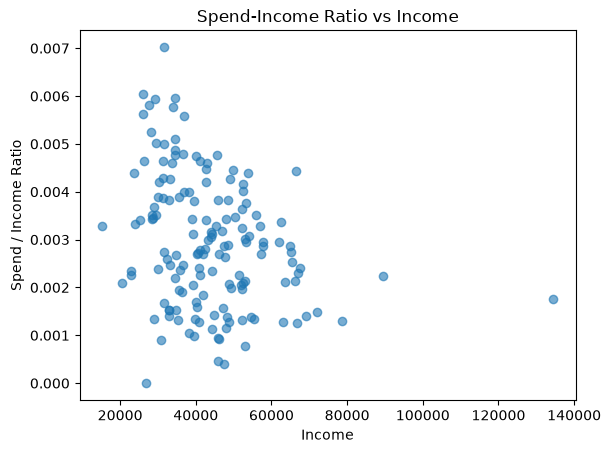

In [ ]:
plt.scatter(df['income'], df['spend_income_ratio'], alpha=0.6)
plt.xlabel('Income')
plt.ylabel('Spend / Income Ratio')
plt.title('Spend-Income Ratio vs Income')
plt.show()

The spend-income ratio varies across income levels, showing that it captures relative spending behavior beyond income alone.

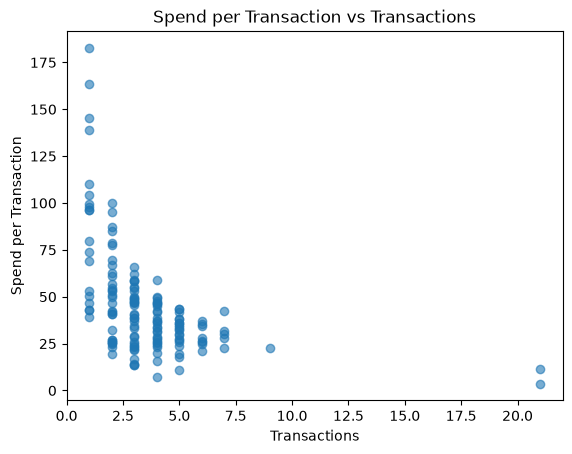

In [ ]:
plt.scatter(df['transactions'], df['spend_per_transaction'], alpha=0.6)
plt.xlabel('Transactions')
plt.ylabel('Spend per Transaction')
plt.title('Spend per Transaction vs Transactions')
plt.show()

Spend per transaction varies across transaction counts, suggesting that transaction frequency alone does not fully explain spending behavior.

In [ ]:
region_cols = [col for col in df.columns if col.startswith('region_')]
print(df[region_cols].sum())

region_East     43
region_North    42
region_South    36
region_West     39
dtype: int64


The one-hot encoded columns preserve the original region categories and allow them to be used as numeric model features without imposing an artificial order.